# Tugas Praktikum 1: Scraping & Eksplorasi Data (EDA)
**Nama:** [Maulana Rhys Pradana]  
**NRP:** [5054251041]  
**Sumber Data:** https://sofifa.com/ (Database Pemain FIFA)

In [3]:
# Scraping Dataset minimum 5 fitur dan 1500 baris, serta menyimpannya ke CSV
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

data_pemain = []

# Mengambil 26 halaman x 60 pemain = 1560 baris[cite: 1]
for page in range(26): 
    offset = page * 60
    url = f"https://sofifa.com/players?offset={offset}"
    
    # User-Agent lengkap agar tidak diblokir oleh sistem keamanan web
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
    }
    
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Mencari spesifik pada bagian isi tabel (tbody) agar terhindar dari error di header
    baris_tabel = soup.select('tbody tr')
    
    for baris in baris_tabel:
        kolom = baris.find_all('td')
        if len(kolom) > 5:
            try:
                # Pencarian yang lebih aman (robust) terhadap perubahan tag
                nama_tag = kolom[1].find('a')
                nama = nama_tag.text.strip() if nama_tag else kolom[1].text.strip()
                
                posisi_tag = baris.find('span', class_='pos')
                posisi = posisi_tag.text.strip() if posisi_tag else "Unknown"
                
                umur = int(kolom[2].text.strip())
                overall = int(kolom[3].text.strip())
                potential = int(kolom[4].text.strip())
                
                data_pemain.append({
                    'Nama': nama,
                    'Posisi': posisi,
                    'Umur': umur,
                    'Overall_Rating': overall,
                    'Potential': potential
                })
            except Exception as e:
                # Mengabaikan baris jika ada data yang kosong/formatnya tidak sesuai
                continue
                
    time.sleep(1) # Polite scraping (memberi jeda agar server tidak down)

df_raw = pd.DataFrame(data_pemain)
df_raw.to_csv('sofifa_dataset.csv', index=False)
print(f"Scraping selesai! Berhasil mengambil {df_raw.shape[0]} baris data dan {df_raw.shape[1]} kolom.")

Scraping selesai! Berhasil mengambil 1553 baris data dan 5 kolom.


In [4]:
# Impor dataset menggunakan pandas dan tampilkan 5 baris pertama[cite: 1]
df = pd.read_csv('sofifa_dataset.csv')
display(df.head())

# Tampilkan info umum dataset (shape, dtypes)[cite: 1]
print("\n--- Informasi Umum Dataset ---")
df.info()

,Nama,Posisi,Umur,Overall_Rating,Potential
0,C. Kostoulas,ST,18,73,85
1,M. Yalcouyé,CM,19,70,79
2,Ricardo Mangas,LM,27,74,74
3,M. Carnesecchi,GK,25,85,88
4,A. Stepanov,ST,17,67,83



--- Informasi Umum Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1553 entries, 0 to 1552
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Nama            1553 non-null   object
 1   Posisi          1553 non-null   object
 2   Umur            1553 non-null   int64 
 3   Overall_Rating  1553 non-null   int64 
 4   Potential       1553 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 60.8+ KB


Tipe dari setiap atribut :
1. **Nama**: Nominal (kategorikal)
2. **Posisi**: Nominal (kategorikal)
3. **Umur**: Numerik (Diskrit)
4. **Overall_Rating**: Numerik (Diskrit)
5. **Potential**: Numerik (Diskrit)

In [5]:
# Hitung statistik deskriptif untuk atribut numerik[cite: 1]
display(df.describe())

# Hitung frekuensi/distribusi untuk atribut kategorikal[cite: 1]
print("\n--- Distribusi Posisi Pemain ---")
display(df['Posisi'].value_counts())

,Umur,Overall_Rating,Potential
count,1553.000000,1553.000000,1553.000000
mean,23.468770,73.503542,79.114617
std,3.544519,6.406154,5.702550
min,16.000000,55.000000,59.000000
25%,21.000000,69.000000,75.000000
50%,23.000000,74.000000,80.000000
75%,25.000000,78.000000,83.000000
max,40.000000,91.000000,95.000000



--- Distribusi Posisi Pemain ---


Posisi
CB     247
ST     213
CM     190
CDM    144
CAM    138
LM     111
LB     111
RM     107
RB      99
GK      86
LW      60
RW      47
Name: count, dtype: int64

--- Missing Values ---
Nama              0
Posisi            0
Umur              0
Overall_Rating    0
Potential         0
dtype: int64


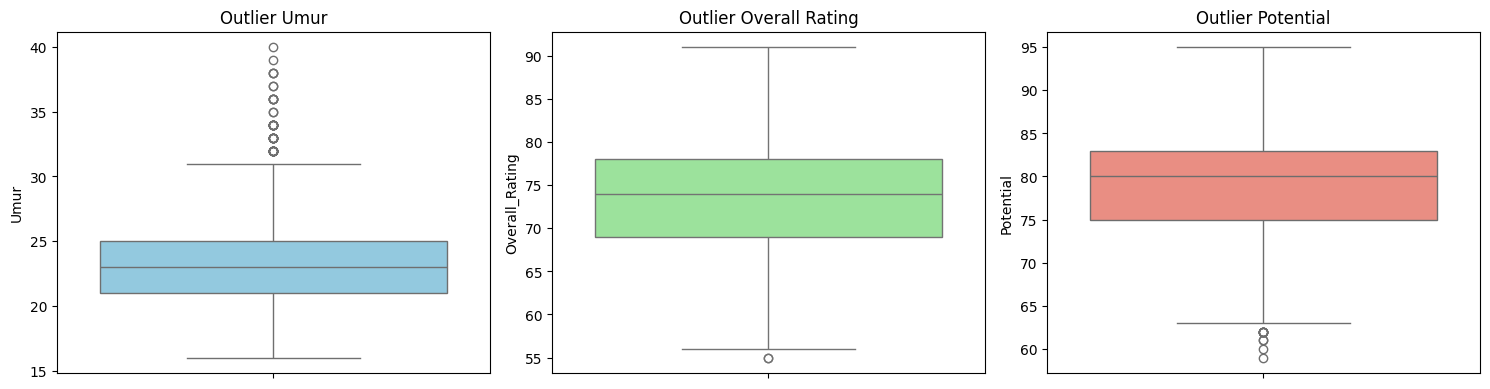

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifikasi jumlah nilai yang hilang pada setiap atribut[cite: 1]
print("--- Missing Values ---")
print(df.isnull().sum())

# Deteksi outlier pada atribut numerik[cite: 1]
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Umur'], color='skyblue')
plt.title('Outlier Umur')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Overall_Rating'], color='lightgreen')
plt.title('Outlier Overall Rating')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Potential'], color='salmon')
plt.title('Outlier Potential')

plt.tight_layout()
plt.show()

In [7]:
# Penanganan nilai yang hilang (hapus baris yang kosong)[cite: 1]
df_bersih = df.dropna()

# Penanganan outlier pada Umur (menghapus data pemain yang usianya tidak masuk akal, misal di atas 45 tahun)[cite: 1]
df_bersih = df_bersih[df_bersih['Umur'] <= 45]

print(f"Bentuk data sebelum dibersihkan: {df.shape}")
print(f"Bentuk data setelah dibersihkan: {df_bersih.shape}")

Bentuk data sebelum dibersihkan: (1553, 5)
Bentuk data setelah dibersihkan: (1553, 5)


C:\Users\eeksa\AppData\Local\Temp\ipykernel_25936\2771226002.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=posisi_top10.values, y=posisi_top10.index, palette='viridis')


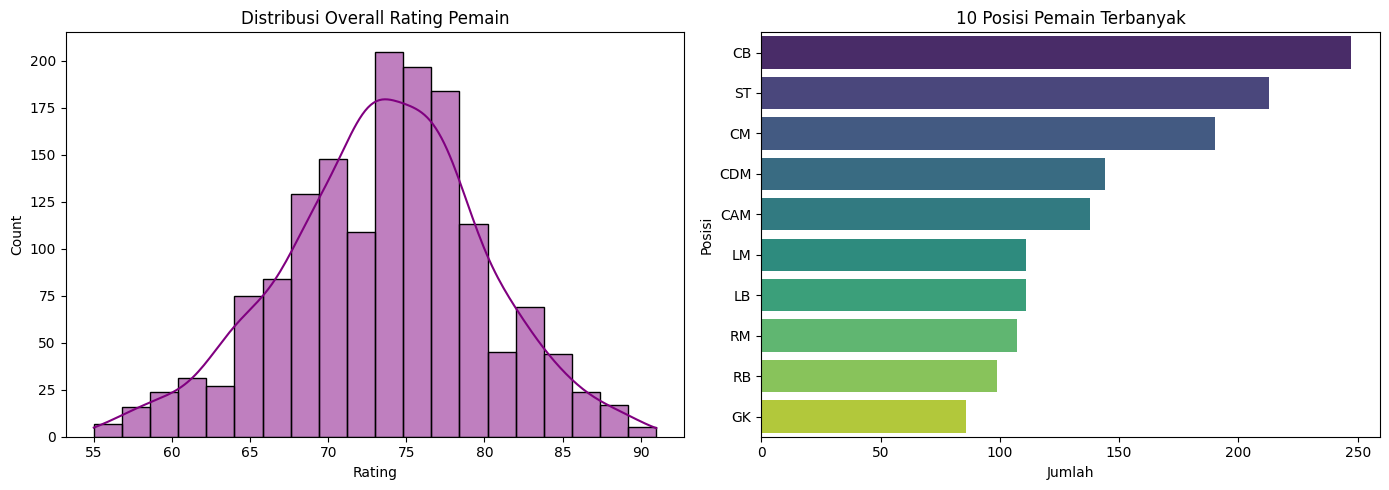

In [8]:
# Visualisasi Univariat[cite: 1]
plt.figure(figsize=(14, 5))

# Histogram/distribusi untuk atribut numerik[cite: 1]
plt.subplot(1, 2, 1)
sns.histplot(df_bersih['Overall_Rating'], bins=20, kde=True, color='purple')
plt.title('Distribusi Overall Rating Pemain')
plt.xlabel('Rating')

# Bar chart untuk atribut kategorikal (menampilkan 10 posisi terbanyak)[cite: 1]
plt.subplot(1, 2, 2)
posisi_top10 = df_bersih['Posisi'].value_counts().head(10)
sns.barplot(x=posisi_top10.values, y=posisi_top10.index, palette='viridis')
plt.title('10 Posisi Pemain Terbanyak')
plt.xlabel('Jumlah')

plt.tight_layout()
plt.show()

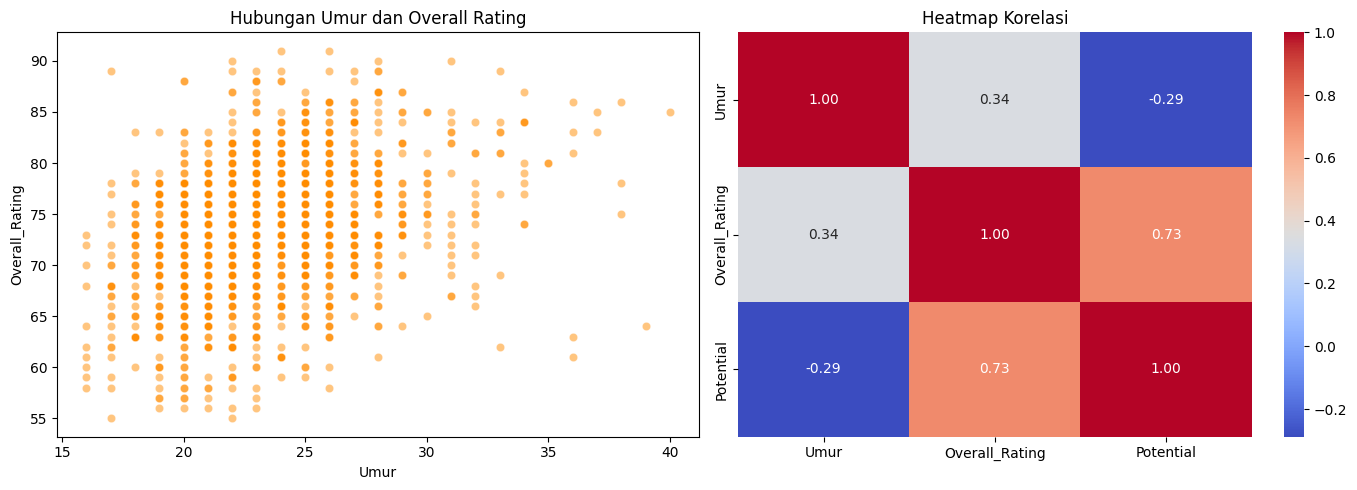

In [9]:
# Visualisasi Bivariat/Hubungan antar atribut[cite: 1]
plt.figure(figsize=(14, 5))

# Scatter plot: hubungan dua atribut numerik[cite: 1]
plt.subplot(1, 2, 1)
sns.scatterplot(x='Umur', y='Overall_Rating', data=df_bersih, alpha=0.5, color='darkorange')
plt.title('Hubungan Umur dan Overall Rating')

# Correlation heatmap[cite: 1]
plt.subplot(1, 2, 2)
sns.heatmap(df_bersih[['Umur', 'Overall_Rating', 'Potential']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

**Interpretasi Visualisasi:**
1. **Histogram:** Distribusi rating pemain memusat (membentuk kurva lonceng) di angka 60 hingga 70, menunjukkan mayoritas pemain di dataset memiliki kemampuan rata-rata.
2. **Bar Chart:** Posisi CB (Center Back) dan ST (Striker) mendominasi jumlah pemain terbanyak dalam dataset.
3. **Scatter Plot:** Terlihat ada tren peningkatan rating seiring bertambahnya usia hingga sekitar umur 28-32 tahun yang merupakan masa emas pemain, setelah itu rating cenderung stagnan atau menurun.
4. **Heatmap:** Terdapat korelasi positif yang cukup kuat antara Overall Rating dan Potential. Namun, Umur dan Potential berkorelasi negatif tinggi (-0.50 atau lebih), artinya semakin tua pemain, potensi mereka untuk berkembang menjadi lebih tinggi semakin kecil.